
# 1.IMPORT LIBRARIES

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import LSTM, Dense
import tensorflow
from keras.models import Sequential
from keras.layers import LSTM, Dense


# 2. LOAD DATA

In [6]:

df = pd.read_csv("train_aWnotuB.csv")

df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values('DateTime')

# Take one junction (example: Junction 1)
df_j1 = df[df['Junction'] == 1]

data = df_j1[['Vehicles']].values

# 3. NORMALIZATION

In [7]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# 4. CREATE SEQUENCES

In [8]:

def create_dataset(data, time_step=24):
    X, y = [], []
    for i in range(len(data)-time_step):
        X.append(data[i:(i+time_step), 0])
        y.append(data[i+time_step, 0])
    return np.array(X), np.array(y)

time_step = 24  # 24 hours
X, y = create_dataset(data_scaled, time_step)

# Reshape for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)

# 5. TRAIN-TEST SPLIT

In [9]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 6. BUILD LSTM MODEL

In [10]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

C:\Users\SUCHITRA KADAM\anaconda3\envs\t_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# 7. TRAIN MODEL

In [11]:

model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
365/365 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - loss: 0.0079
Epoch 2/10
365/365 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0017
Epoch 3/10
365/365 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0014
Epoch 4/10
365/365 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0011
Epoch 5/10
365/365 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0011
Epoch 6/10
365/365 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 9.8290e-04
Epoch 7/10
365/365 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 9.7675e-04
Epoch 8/10
365/365 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.0010
Epoch 9/10
365/365 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 9.2199e-04
Epoch 10/10
365/365 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 9.1321e-04


# 8. PREDICTION

In [12]:

train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Convert back to original scale
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

y_train_actual = scaler.inverse_transform(y_train.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

365/365 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


# 9. EVALUATION

In [13]:

rmse = np.sqrt(mean_squared_error(y_test_actual, test_predict))
print("RMSE:", rmse)


RMSE: 5.718224858396929


# 10. PLOT RESULTS

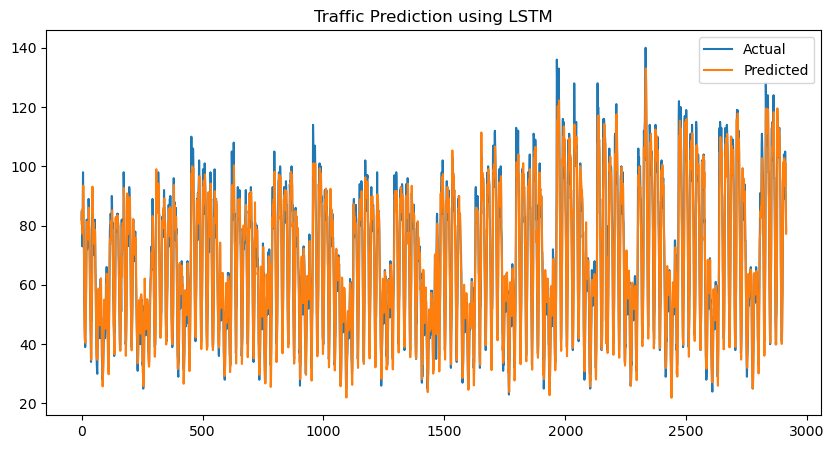

In [14]:

plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label='Actual')
plt.plot(test_predict, label='Predicted')
plt.legend()
plt.title("Traffic Prediction using LSTM")
plt.show()